<a href="https://colab.research.google.com/github/CaoRIV/machine-learning-practicals/blob/main/01_Bai_tap_Gapminder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hệ thống bài tập Hồi quy tuyến tính với dữ liệu Gapminder

**Phiên bản người học**  
Biến đích chính: `lifeExp`. Mục tiêu dự báo: tuổi thọ kỳ vọng của các quốc gia ở các thời điểm tương lai.

Quy tắc quan trọng: chỉ dùng `train` để ước lượng, dùng `validation` để lựa chọn mô hình và chỉ mở `test` sau khi đã khóa mọi quyết định.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Đang chạy trên môi trường local.")

Đang chạy trên môi trường local.


In [2]:
import sys
print(sys.executable)

d:\Python3\python.exe


In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

#DATA_CANDIDATES = [Path("../data"), Path("data"), Path("."), Path("/content/")]
DATA_CANDIDATES = [
    Path("data"),
    Path("../data"),
    Path(".")
]
DATA_DIR = next((p.resolve() for p in DATA_CANDIDATES if (p / "gapminder_full_1952_2007.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Không tìm thấy thư mục dữ liệu. Hãy đặt bốn tệp CSV trong ../data hoặc data.")
print("Thư mục dữ liệu:", DATA_DIR)

full = pd.read_csv(DATA_DIR / "gapminder_full_1952_2007.csv")
train = pd.read_csv(DATA_DIR / "gapminder_train_1952_1997.csv")
validation = pd.read_csv(DATA_DIR / "gapminder_validation_2002.csv")
test = pd.read_csv(DATA_DIR / "gapminder_test_2007.csv")

def engineer(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["log2_gdp"] = np.log2(out["gdpPercap"])
    out["log2_gdp_sq"] = out["log2_gdp"] ** 2
    out["log10_pop"] = np.log10(out["pop"])
    out["time5"] = (out["year"] - 1952) / 5
    return out

train_e = engineer(train)
validation_e = engineer(validation)
test_e = engineer(test)
full_e = engineer(full)

def regression_metrics(y_true, y_pred) -> pd.Series:
    return pd.Series({
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    })

Thư mục dữ liệu: D:\machine-learning-practicals\data


## Mô-đun 1 — Kiểm toán dữ liệu và phân tích khám phá (15 điểm)

### B1. Hồ sơ bốn tệp dữ liệu — 3 điểm
Tạo bảng gồm: tên tập, số dòng, số cột, số quốc gia, các năm, số giá trị thiếu và số dòng trùng lặp.

In [4]:
datasets = {
    "full": full,
    "train": train,
    "validation": validation,
    "test": test
}

rows = []

for name, df in datasets.items():
    rows.append({
        "Tập dữ liệu": name,
        "Số dòng": df.shape[0],
        "Số cột": df.shape[1],
        "Số quốc gia": df["country"].nunique(),
        "Các năm": sorted(df["year"].unique()),
        "Số giá trị thiếu": df.isna().sum().sum(),
        "Số dòng trùng lặp": df.duplicated().sum()
    })

profile = pd.DataFrame(rows)
display(profile)

,Tập dữ liệu,Số dòng,Số cột,Số quốc gia,Các năm,Số giá trị thiếu,Số dòng trùng lặp
0,full,1704,6,142,"[1952, 1957, 1962, 1967, 1972, 1977, 1982, 198...",0,0
1,train,1420,6,142,"[1952, 1957, 1962, 1967, 1972, 1977, 1982, 198...",0,0
2,validation,142,6,142,[2002],0,0
3,test,142,6,142,[2007],0,0


### B2. Kiểm chứng phép chia theo thời gian — 2 điểm

1. Chứng minh các cặp `(country, year)` giữa train, validation và test không giao nhau.
2. Kiểm tra hợp của ba tập có đúng bằng tập full hay không.
3. Giải thích vì sao phép chia này phù hợp hơn phép chia ngẫu nhiên cho bài toán dự báo tương lai.

In [5]:
train_keys = set(zip(train["country"], train["year"]))
validation_keys = set(zip(validation["country"], validation["year"]))
test_keys = set(zip(test["country"], test["year"]))

print("Số khóa chung giữa train và validation:", len(train_keys & validation_keys))
print("Số khóa chung giữa train và test:", len(train_keys & test_keys))
print("Số khóa chung giữa validation và test:", len(validation_keys & test_keys))

combined = pd.concat([train, validation, test], ignore_index=True)
combined = combined.sort_values(["country", "year"]).reset_index(drop=True)
full_sorted = full.sort_values(["country", "year"]).reset_index(drop=True)

print("Hợp train, validation và test bằng full:", combined.equals(full_sorted))

print("""
Phép chia theo thời gian phù hợp vì mô hình chỉ học từ các năm trong
quá khứ và được đánh giá trên các năm tương lai. Nếu chia ngẫu nhiên,
các quan sát của cùng một quốc gia ở những năm gần nhau có thể xuất hiện
trong cả train và validation, làm kết quả đánh giá lạc quan hơn thực tế.
""")

Số khóa chung giữa train và validation: 0
Số khóa chung giữa train và test: 0
Số khóa chung giữa validation và test: 0
Hợp train, validation và test bằng full: True

Phép chia theo thời gian phù hợp vì mô hình chỉ học từ các năm trong
quá khứ và được đánh giá trên các năm tương lai. Nếu chia ngẫu nhiên,
các quan sát của cùng một quốc gia ở những năm gần nhau có thể xuất hiện
trong cả train và validation, làm kết quả đánh giá lạc quan hơn thực tế.



### B3. Kiểm tra dữ liệu bảng cân bằng — 2 điểm

Đếm số mốc thời gian của từng quốc gia trong `full` và `train`. Có quốc gia nào thiếu mốc năm hay không?

In [6]:
full_periods = full.groupby("country")["year"].nunique()
train_periods = train.groupby("country")["year"].nunique()

print("Số mốc thời gian trong full:")
display(full_periods.value_counts().sort_index())

print("Số mốc thời gian trong train:")
display(train_periods.value_counts().sort_index())

missing_in_full = full_periods[full_periods < full["year"].nunique()]
missing_in_train = train_periods[train_periods < train["year"].nunique()]

print("Số quốc gia thiếu mốc năm trong full:", len(missing_in_full))
print("Số quốc gia thiếu mốc năm trong train:", len(missing_in_train))
print("Kết luận: dữ liệu là bảng cân bằng, không quốc gia nào thiếu mốc năm.")

Số mốc thời gian trong full:


year
12    142
Name: count, dtype: int64

Số mốc thời gian trong train:


year
10    142
Name: count, dtype: int64

Số quốc gia thiếu mốc năm trong full: 0
Số quốc gia thiếu mốc năm trong train: 0
Kết luận: dữ liệu là bảng cân bằng, không quốc gia nào thiếu mốc năm.


### B4. Từ điển biến và thang đo — 2 điểm

Phân loại từng biến theo: định danh, định tính danh nghĩa, định lượng rời rạc, định lượng liên tục. Chọn biến đích và giải thích vì sao `country` không nên được coi như một số thông thường.

| Biến | Phân loại | Ý nghĩa |
|---|---|---|
| `country` | Định danh | Tên quốc gia |
| `year` | Định lượng rời rạc | Năm quan sát |
| `pop` | Định lượng rời rạc | Dân số |
| `continent` | Định tính danh nghĩa | Châu lục |
| `lifeExp` | Định lượng liên tục | Tuổi thọ kỳ vọng, đơn vị năm |
| `gdpPercap` | Định lượng liên tục | GDP bình quân đầu người |

Biến đích được chọn là `lifeExp` vì mục tiêu của bài toán là dự báo tuổi thọ kỳ vọng.

`country` không nên được xem như một số thông thường. Nếu mã hóa các quốc gia thành 1, 2, 3 thì mô hình sẽ hiểu sai rằng giữa các quốc gia tồn tại thứ tự và khoảng cách số học. Nếu đưa `country` vào mô hình, cần xử lý nó như biến phân loại bằng biến giả hoặc hiệu ứng cố định quốc gia.

### B5. Phân phối và phép biến đổi — 3 điểm

1. Tính mean, median, standard deviation, min, max và skewness cho `lifeExp`, `gdpPercap`, `pop` trên train.
2. So sánh skewness trước và sau khi dùng log.
3. Vẽ riêng từng biểu đồ: histogram GDP thô, histogram log-GDP, scatter tuổi thọ–GDP thô, scatter tuổi thọ–log-GDP.

,mean,median,std,min,max,skew
lifeExp,58.0991,59.1320,12.6228,23.5990,80.6900,-0.2157
gdpPercap,"6,498.6005","3,194.2696","9,196.8378",298.8462,"113,523.1329",4.9508
pop,"26,973,573.9739","6,393,459.0000","96,677,684.5430","60,011.0000","1,230,075,000.0000",8.3035


,Biến,Skewness trước log,Skewness sau log
0,gdpPercap,4.9508,0.1294
1,pop,8.3035,0.0794


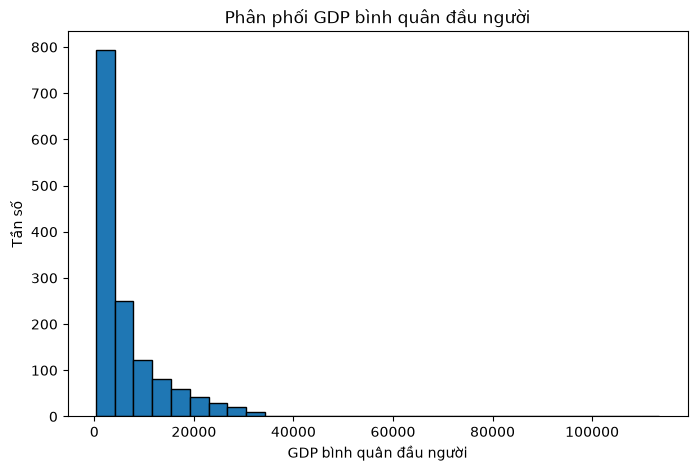

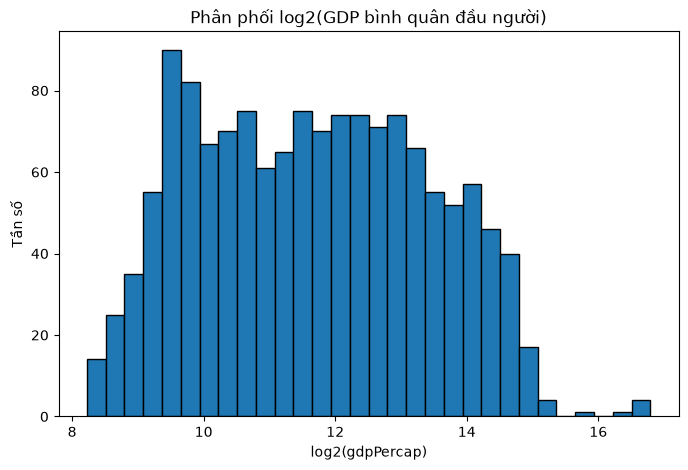

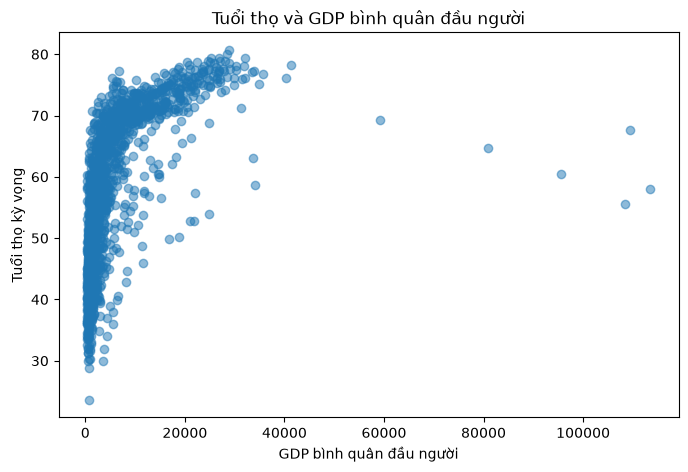

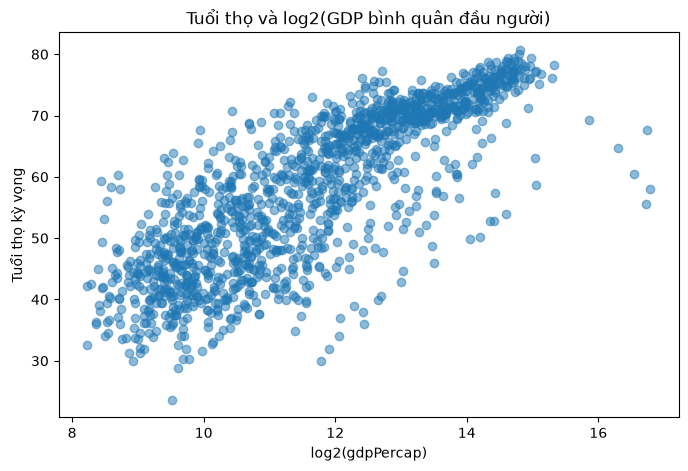


GDP/người và dân số trên thang đo gốc có phân phối lệch phải mạnh.
Sau phép biến đổi log, skewness giảm đáng kể. Quan hệ giữa lifeExp
và log2(gdpPercap) cũng gần tuyến tính hơn quan hệ dùng GDP thô.



In [7]:
variables = ["lifeExp", "gdpPercap", "pop"]

summary_stats = train[variables].agg(["mean", "median", "std", "min", "max", "skew"]).T
display(summary_stats)

skewness_comparison = pd.DataFrame({
    "Biến": ["gdpPercap", "pop"],
    "Skewness trước log": [train["gdpPercap"].skew(), train["pop"].skew()],
    "Skewness sau log": [train_e["log2_gdp"].skew(), train_e["log10_pop"].skew()]
})
display(skewness_comparison)

plt.figure(figsize=(8, 5))
plt.hist(train["gdpPercap"], bins=30, edgecolor="black")
plt.title("Phân phối GDP bình quân đầu người")
plt.xlabel("GDP bình quân đầu người")
plt.ylabel("Tần số")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train_e["log2_gdp"], bins=30, edgecolor="black")
plt.title("Phân phối log2(GDP bình quân đầu người)")
plt.xlabel("log2(gdpPercap)")
plt.ylabel("Tần số")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(train["gdpPercap"], train["lifeExp"], alpha=0.5)
plt.title("Tuổi thọ và GDP bình quân đầu người")
plt.xlabel("GDP bình quân đầu người")
plt.ylabel("Tuổi thọ kỳ vọng")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(train_e["log2_gdp"], train_e["lifeExp"], alpha=0.5)
plt.title("Tuổi thọ và log2(GDP bình quân đầu người)")
plt.xlabel("log2(gdpPercap)")
plt.ylabel("Tuổi thọ kỳ vọng")
plt.show()

print("""
GDP/người và dân số trên thang đo gốc có phân phối lệch phải mạnh.
Sau phép biến đổi log, skewness giảm đáng kể. Quan hệ giữa lifeExp
và log2(gdpPercap) cũng gần tuyến tính hơn quan hệ dùng GDP thô.
""")

### B6. Khác biệt theo thời gian và châu lục — 3 điểm

Tạo bảng trung bình tuổi thọ theo năm và theo châu lục; vẽ đường xu hướng trung bình theo năm. Thảo luận liệu một hệ số thời gian chung cho mọi châu lục có hợp lý hay không.

Tuổi thọ trung bình theo năm:


,year,mean_lifeExp
0,1952,49.0576
1,1957,51.5074
2,1962,53.6092
3,1967,55.6783
4,1972,57.6474
5,1977,59.5702
6,1982,61.5332
7,1987,63.2126
8,1992,64.1603
9,1997,65.0147


Tuổi thọ trung bình theo châu lục:


,continent,mean_lifeExp
0,Africa,47.8253
1,Americas,62.9875
2,Asia,58.0816
3,Europe,70.8495
4,Oceania,73.1455


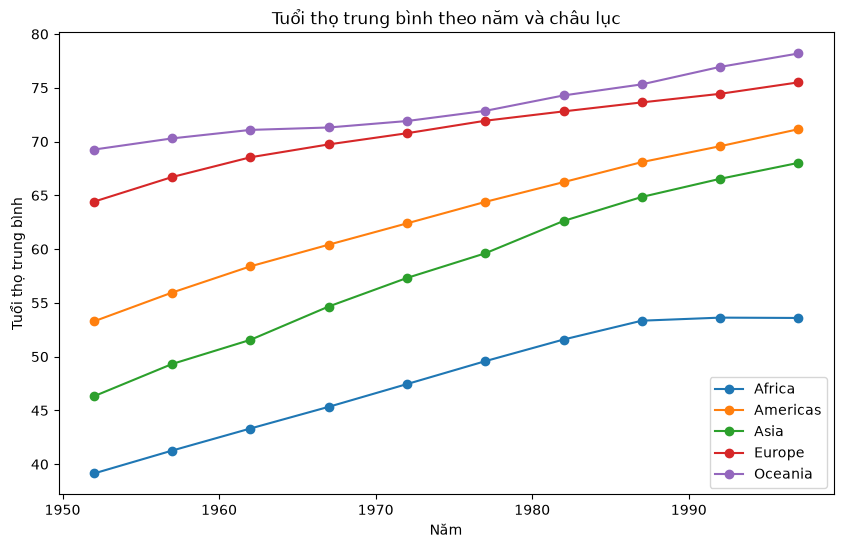


Tuổi thọ trung bình nhìn chung tăng theo thời gian, nhưng các châu lục
có mức ban đầu và đường xu hướng khác nhau. Vì vậy, một hệ số thời gian
chung là giả định đơn giản nhưng có thể chưa phù hợp hoàn toàn. Có thể
kiểm tra bằng tương tác giữa time5 và continent ở mô hình sau.



In [8]:
mean_by_year = train.groupby("year", as_index=False).agg(mean_lifeExp=("lifeExp", "mean"))
mean_by_continent = train.groupby("continent", as_index=False).agg(mean_lifeExp=("lifeExp", "mean"))
mean_by_year_continent = train.groupby(["year", "continent"], as_index=False).agg(mean_lifeExp=("lifeExp", "mean"))

print("Tuổi thọ trung bình theo năm:")
display(mean_by_year)

print("Tuổi thọ trung bình theo châu lục:")
display(mean_by_continent)

plt.figure(figsize=(10, 6))

for continent, group in mean_by_year_continent.groupby("continent"):
    plt.plot(group["year"], group["mean_lifeExp"], marker="o", label=continent)

plt.title("Tuổi thọ trung bình theo năm và châu lục")
plt.xlabel("Năm")
plt.ylabel("Tuổi thọ trung bình")
plt.legend()
plt.show()

print("""
Tuổi thọ trung bình nhìn chung tăng theo thời gian, nhưng các châu lục
có mức ban đầu và đường xu hướng khác nhau. Vì vậy, một hệ số thời gian
chung là giả định đơn giản nhưng có thể chưa phù hợp hoàn toàn. Có thể
kiểm tra bằng tương tác giữa time5 và continent ở mô hình sau.
""")

## Mô-đun 2 — Hồi quy tuyến tính đơn (20 điểm)

### B7. Mô hình nền trung bình — 3 điểm

Dùng tuổi thọ trung bình của train làm dự báo cho mọi quan sát. Tính MAE, RMSE, R² trên train và validation. Giải thích vì sao R² validation có thể âm.

In [9]:
train_mean = train["lifeExp"].mean()

train_pred_b7 = np.full(len(train), train_mean)
validation_pred_b7 = np.full(len(validation), train_mean)

b7_metrics = pd.DataFrame({
    "Train": regression_metrics(train["lifeExp"], train_pred_b7),
    "Validation": regression_metrics(validation["lifeExp"], validation_pred_b7)
}).T

print(f"Tuổi thọ trung bình của train: {train_mean:.4f}")
display(b7_metrics)

print("""
R² validation có thể âm vì dự báo bằng trung bình của train có tổng sai số
bình phương lớn hơn dự báo bằng trung bình thực tế của validation. Khi đó
mô hình hoạt động kém hơn mô hình tham chiếu dùng trung bình validation.
""")

Tuổi thọ trung bình của train: 58.0991


,MAE,RMSE,R2
Train,11.0539,12.6183,0.0000
Validation,12.9891,14.4024,-0.3853



R² validation có thể âm vì dự báo bằng trung bình của train có tổng sai số
bình phương lớn hơn dự báo bằng trung bình thực tế của validation. Khi đó
mô hình hoạt động kém hơn mô hình tham chiếu dùng trung bình validation.



### B8. Tự tính OLS — 4 điểm

Với mô hình `lifeExp = β0 + β1*gdpPercap + ε`, tự tính `β0`, `β1` bằng công thức OLS, sau đó đối chiếu với `LinearRegression` hoặc `statsmodels`.

In [10]:
x = train["gdpPercap"]
y = train["lifeExp"]

x_mean = x.mean()
y_mean = y.mean()

beta_1_manual = (((x - x_mean) * (y - y_mean)).sum()
                 / ((x - x_mean) ** 2).sum())
beta_0_manual = y_mean - beta_1_manual * x_mean

model_b8_sklearn = LinearRegression()
model_b8_sklearn.fit(train[["gdpPercap"]], train["lifeExp"])

b8_comparison = pd.DataFrame({
    "Phương pháp": ["Tính bằng công thức OLS", "LinearRegression"],
    "beta_0": [beta_0_manual, model_b8_sklearn.intercept_],
    "beta_1": [beta_1_manual, model_b8_sklearn.coef_[0]]
})

display(b8_comparison)

,Phương pháp,beta_0,beta_1
0,Tính bằng công thức OLS,53.2269,0.0007
1,LinearRegression,53.2269,0.0007


### B9. GDP thô và ý nghĩa hệ số — 3 điểm

Ước lượng mô hình trên train. Diễn giải tác động liên hệ của GDP/người tăng 1.000 đơn vị. Đánh giá validation và quan sát đồ thị phần dư.

,Hệ số,Sai số chuẩn,p-value
Intercept,53.2269,0.3437,0.0000
gdpPercap,0.0007,0.0000,0.0000


,Validation
MAE,8.9530
RMSE,10.2685
R2,0.2958


Khi GDP/người tăng 1.000 đơn vị, tuổi thọ dự báo tăng khoảng 0.7497 năm.


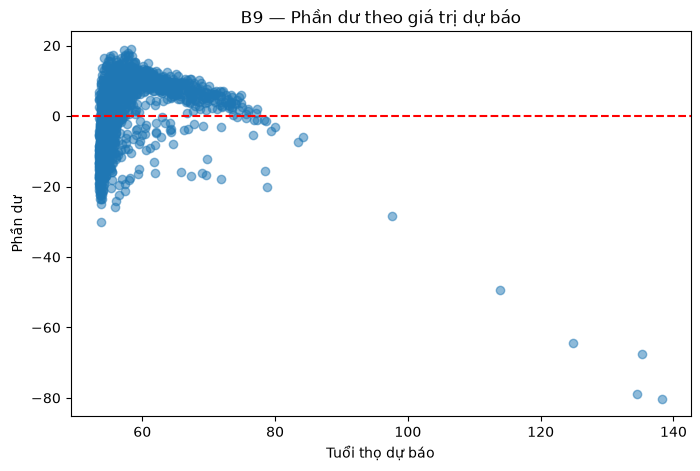

In [11]:
model_b9 = smf.ols("lifeExp ~ gdpPercap", data=train).fit()

validation_pred_b9 = model_b9.predict(validation)
b9_metrics = regression_metrics(validation["lifeExp"], validation_pred_b9)

b9_coefficients = pd.DataFrame({
    "Hệ số": model_b9.params,
    "Sai số chuẩn": model_b9.bse,
    "p-value": model_b9.pvalues
})

display(b9_coefficients)
display(b9_metrics.to_frame("Validation"))

effect_1000 = model_b9.params["gdpPercap"] * 1000
print(f"Khi GDP/người tăng 1.000 đơn vị, tuổi thọ dự báo tăng khoảng {effect_1000:.4f} năm.")

train_pred_b9 = model_b9.predict(train)
residual_b9 = train["lifeExp"] - train_pred_b9

plt.figure(figsize=(8, 5))
plt.scatter(train_pred_b9, residual_b9, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.title("B9 — Phần dư theo giá trị dự báo")
plt.xlabel("Tuổi thọ dự báo")
plt.ylabel("Phần dư")
plt.show()

### B10. Mô hình log-GDP — 4 điểm

Ước lượng `lifeExp ~ log2(gdpPercap)`. Diễn giải hệ số dốc theo câu: “khi GDP/người tăng gấp đôi…”. So sánh với B9 bằng RMSE validation và R² validation.

In [12]:
model_b10 = smf.ols("lifeExp ~ log2_gdp", data=train_e).fit()

validation_pred_b10 = model_b10.predict(validation_e)
b10_metrics = regression_metrics(validation_e["lifeExp"], validation_pred_b10)

b10_coefficients = pd.DataFrame({
    "Hệ số": model_b10.params,
    "Sai số chuẩn": model_b10.bse,
    "p-value": model_b10.pvalues
})
display(b10_coefficients)

b9_b10_comparison = pd.DataFrame({
    "B9 — GDP thô": b9_metrics,
    "B10 — log2(GDP)": b10_metrics
}).T
display(b9_b10_comparison)

doubling_effect = model_b10.params["log2_gdp"]
print(f"Khi GDP/người tăng gấp đôi, tuổi thọ dự báo tăng khoảng {doubling_effect:.4f} năm.")

,Hệ số,Sai số chuẩn,p-value
Intercept,-9.9677,1.3487,0.0000
log2_gdp,5.8367,0.1144,0.0000


,MAE,RMSE,R2
B9 — GDP thô,8.9530,10.2685,0.2958
B10 — log2(GDP),6.8219,8.2922,0.5408


Khi GDP/người tăng gấp đôi, tuổi thọ dự báo tăng khoảng 5.8367 năm.


### B11. Dự báo trường hợp Việt Nam — 3 điểm

Dùng mô hình B10 dự báo tuổi thọ Việt Nam năm 2002. Tính sai số có dấu và sai số tuyệt đối. Giải thích nguyên nhân mô hình một biến có thể dự báo thấp đáng kể.

In [13]:
vietnam_2002 = validation_e[validation_e["country"] == "Vietnam"].copy()

actual_b11 = vietnam_2002["lifeExp"].iloc[0]
predicted_b11 = model_b10.predict(vietnam_2002).iloc[0]
signed_error_b11 = predicted_b11 - actual_b11
absolute_error_b11 = abs(signed_error_b11)

b11_result = pd.DataFrame({
    "Quốc gia": ["Vietnam"],
    "Năm": [2002],
    "Tuổi thọ thực tế": [actual_b11],
    "Tuổi thọ dự báo": [predicted_b11],
    "Sai số có dấu": [signed_error_b11],
    "Sai số tuyệt đối": [absolute_error_b11]
})
display(b11_result)

print("""
Sai số có dấu được tính bằng dự báo trừ thực tế. Sai số âm nghĩa là mô hình
dự báo thấp hơn thực tế. Mô hình B10 chỉ sử dụng GDP/người nên chưa xét xu
hướng thời gian, đặc điểm châu lục, dân số và đặc trưng riêng của Việt Nam.
""")

,Quốc gia,Năm,Tuổi thọ thực tế,Tuổi thọ dự báo,Sai số có dấu,Sai số tuyệt đối
0,Vietnam,2002,73.0170,52.9816,-20.0354,20.0354



Sai số có dấu được tính bằng dự báo trừ thực tế. Sai số âm nghĩa là mô hình
dự báo thấp hơn thực tế. Mô hình B10 chỉ sử dụng GDP/người nên chưa xét xu
hướng thời gian, đặc điểm châu lục, dân số và đặc trưng riêng của Việt Nam.



### B12. Khoảng tin cậy và khoảng dự báo — 3 điểm

Dùng `statsmodels` tính khoảng tin cậy 95% của trung bình và khoảng dự báo 95% cho một quan sát Việt Nam năm 2002. Giải thích vì sao khoảng dự báo rộng hơn.

In [14]:
prediction_b12 = model_b10.get_prediction(vietnam_2002).summary_frame(alpha=0.05)

b12_result = prediction_b12[[
    "mean", "mean_ci_lower", "mean_ci_upper",
    "obs_ci_lower", "obs_ci_upper"
]].rename(columns={
    "mean": "Dự báo",
    "mean_ci_lower": "Cận dưới khoảng tin cậy 95%",
    "mean_ci_upper": "Cận trên khoảng tin cậy 95%",
    "obs_ci_lower": "Cận dưới khoảng dự báo 95%",
    "obs_ci_upper": "Cận trên khoảng dự báo 95%"
})
display(b12_result)

confidence_width = prediction_b12["mean_ci_upper"].iloc[0] - prediction_b12["mean_ci_lower"].iloc[0]
prediction_width = prediction_b12["obs_ci_upper"].iloc[0] - prediction_b12["obs_ci_lower"].iloc[0]

print(f"Độ rộng khoảng tin cậy: {confidence_width:.4f}")
print(f"Độ rộng khoảng dự báo: {prediction_width:.4f}")

print("""
Khoảng dự báo rộng hơn vì nó bao gồm cả sự không chắc chắn khi ước lượng
tuổi thọ trung bình và biến động riêng của một quan sát quốc gia. Khoảng
tin cậy chỉ phản ánh sự không chắc chắn của giá trị trung bình dự báo.
""")

,Dự báo,Cận dưới khoảng tin cậy 95%,Cận trên khoảng tin cậy 95%,Cận dưới khoảng dự báo 95%,Cận trên khoảng dự báo 95%
137,52.9816,52.5445,53.4187,38.2671,67.6962


Độ rộng khoảng tin cậy: 0.8742
Độ rộng khoảng dự báo: 29.4291

Khoảng dự báo rộng hơn vì nó bao gồm cả sự không chắc chắn khi ước lượng
tuổi thọ trung bình và biến động riêng của một quan sát quốc gia. Khoảng
tin cậy chỉ phản ánh sự không chắc chắn của giá trị trung bình dự báo.



## Mô-đun 3 — Hồi quy đa biến và kỹ thuật đặc trưng (25 điểm)

### B13. Bổ sung xu hướng thời gian — 4 điểm

Dùng `time5 = (year-1952)/5` và ước lượng `lifeExp ~ log2_gdp + time5`. Diễn giải hai hệ số và so sánh validation với mô hình B10.

In [15]:
# TODO B13

### B14. Biến giả châu lục — 4 điểm

Thêm `C(continent)` với Africa làm nhóm tham chiếu. Viết đầy đủ phương trình cho một quốc gia châu Á và giải thích hệ số châu lục không phải là tác động nhân quả.

In [16]:
# TODO B14

### B15. Mô hình đa biến chính — 4 điểm

Ước lượng:

\[
lifeExp = \beta_0 + \beta_1\log_2(gdpPercap)+\beta_2 time5+\beta_3\log_{10}(pop)+\gamma^\top continent+\varepsilon.
\]

Báo cáo hệ số, adjusted R² train và ba chỉ số validation.

In [17]:
# TODO B15

### B16. Hệ số chuẩn hóa — 3 điểm

Chuẩn hóa các biến số và so sánh độ lớn hệ số. Nêu rõ vì sao không chuẩn hóa biến đích vẫn có thể hữu ích khi cần diễn giải theo đơn vị năm tuổi thọ.

In [18]:
# TODO B16

### B17. Quan hệ phi tuyến nhưng vẫn tuyến tính theo tham số — 4 điểm

Thêm `log2_gdp_sq = log2_gdp**2`. Kiểm tra dấu của hệ số bậc hai và diễn giải hiện tượng lợi ích biên giảm dần. So sánh validation với B15.

In [19]:
# TODO B17

### B18. Tương tác theo châu lục — 3 điểm

Cho phép hệ số `log2_gdp` và `time5` khác nhau giữa các châu lục. Dùng validation để đánh giá liệu độ phức tạp tăng thêm có đáng giá hay không.

In [20]:
# TODO B18

### B19. Hiệu ứng cố định quốc gia — 3 điểm

Thêm biến giả `country` hoặc dùng Ridge với one-hot quốc gia. So sánh hai mục tiêu triển khai:

- dự báo tương lai cho **các quốc gia đã biết**;
- dự báo cho **một quốc gia mới chưa từng xuất hiện**.

In [21]:
# TODO B19

## Mô-đun 4 — Chẩn đoán và suy luận thống kê (20 điểm)

### B20. Đồ thị chẩn đoán — 4 điểm
Với mô hình B15, vẽ riêng: residual–fitted, Q–Q plot, residual theo năm và histogram phần dư. Chỉ ra các vi phạm giả định có thể có.

In [22]:
# TODO B20

### B21. Phương sai thay đổi — 3 điểm
Thực hiện kiểm định Breusch–Pagan; so sánh standard error OLS với HC3. Kết luận về suy luận thống kê.

In [23]:
# TODO B21

### B22. Đa cộng tuyến — 3 điểm
Tính VIF cho ma trận thiết kế của B15. Phân biệt VIF cao của intercept với VIF của các biến giải thích.

In [24]:
# TODO B22

### B23. Điểm ảnh hưởng — 3 điểm
Tính Cook's distance; liệt kê 10 quan sát ảnh hưởng nhất và tìm hiểu vì sao Kuwait, Rwanda hoặc Cambodia có thể xuất hiện.

In [25]:
# TODO B23

### B24. Sai số có cấu trúc — 3 điểm
Tính MAE và bias trung bình theo châu lục và theo năm. Mô hình có liên tục dự báo cao hoặc thấp cho nhóm nào không?

In [26]:
# TODO B24

### B25. Sai số chuẩn phân cụm theo quốc gia — 4 điểm
Do mỗi quốc gia xuất hiện nhiều lần, tính cluster-robust standard errors theo `country` và so sánh với OLS/HC3. Hệ số nào thay đổi kết luận đáng kể?

In [27]:
# TODO B25

## Mô-đun 5 — Đánh giá theo thời gian và dữ liệu bảng (20 điểm)

### B26. Chia ngẫu nhiên so với chia theo thời gian — 4 điểm
So sánh Mô hình B15 trên một random split 80/20 với đánh giá validation 2002. Giải thích cơ chế gây lạc quan của random split.

In [28]:
# TODO B26

### B27. Bảng lựa chọn mô hình — 4 điểm
Lập bảng cho ít nhất sáu mô hình: baseline, GDP thô, log-GDP, log-GDP + time, mô hình đa biến, mô hình bậc hai. Chọn mô hình bằng validation theo một quy tắc đã nêu trước.

In [29]:
# TODO B27

### B28. Đánh giá test một lần — 4 điểm
Sau khi khóa mô hình, đánh giá năm 2007. Báo cáo MAE, RMSE, R², biểu đồ actual–predicted và năm quốc gia có sai số tuyệt đối lớn nhất.

In [30]:
# TODO B28

### B29. Hiệu năng theo châu lục — 4 điểm
Tính MAE/RMSE theo châu lục trên test. Không diễn giải R² cho nhóm chỉ có rất ít quan sát mà không kèm cảnh báo. Đề xuất một cải tiến mô hình.

In [31]:
# TODO B29

### B30. Tổng quát hóa sang quốc gia mới — 4 điểm
Dùng `GroupKFold` với nhóm là `country`. So sánh kết quả với temporal split và giải thích hai phép đánh giá trả lời hai câu hỏi triển khai khác nhau.

In [32]:
# TODO B30

## Mô-đun 6 — Dự án tổng hợp

### P1. Nghiên cứu trường hợp Việt Nam
Phân tích quỹ đạo 1952–2007, so sánh actual–predicted, nhận diện giai đoạn mô hình sai nhiều và viết một báo cáo 800–1.200 từ.

### P2. Mô phỏng “GDP tăng gấp đôi”
Dùng mô hình đa biến để mô phỏng thay đổi dự báo tuổi thọ khi GDP/người tăng gấp đôi. Phải có một mục riêng giải thích vì sao đây **không phải** ước lượng tác động chính sách nhân quả.

### P3. Báo cáo nghiên cứu tái lập
Viết báo cáo theo cấu trúc: câu hỏi, dữ liệu, phương pháp, validation, chẩn đoán, test, giới hạn và hướng mở rộng. Nộp notebook có thể chạy từ đầu đến cuối.

## Tiêu chí chấm chung

- Đúng quy trình train–validation–test: 25%.
- Mã chạy được, tái lập và có kiểm tra dữ liệu: 20%.
- Diễn giải hệ số đúng điều kiện “giữ các biến khác không đổi”: 20%.
- Chẩn đoán giả định và thảo luận dữ liệu bảng: 20%.
- Trình bày rõ, bảng/biểu đồ có nhãn và không diễn giải nhân quả quá mức: 15%.